# Phase A-3: Match Score + 行为生成 + 验证

## 目标
1. 定义 match_score(u,i) 公式，计算用户-物品匹配度
2. 用真实 ID 拟合权重，验证 hold-out 物品排序
3. 行为漏斗：match_score → 交互概率 → 生成交互记录
4. 验证策略 B：LR 恢复 latent 权重

## Match Score 公式
```
match_score = σ(
    w1·cos_sim(theme_u, theme_i)       # 主题匹配
  + w2·(1 - |budget - price|)           # 价格匹配
  + w3·cos_sim(skill_u, skill_i)        # 技能匹配
  + w4·quality_sens × quality_score     # 质量匹配
  + w5·ct_pref[type(i)]                 # 类型偏好
  + w6·popularity                       # 热门加成
  - w7·(1 - freshness)                  # 陈旧惩罚
)
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, ndcg_score
from sklearn.preprocessing import StandardScaler
from scipy.special import expit as sigmoid
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = ['SimHei', 'Microsoft YaHei', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

DATA_DIR = '../data'
print('Setup OK')

Setup OK


In [2]:
# 加载 A-1 和 A-2 的输出
user_latent = pd.read_csv(f'{DATA_DIR}/user_latent.csv', index_col='user_id')
item_latent = pd.read_csv(f'{DATA_DIR}/item_latent.csv', index_col='item_id')
user_segments = pd.read_csv(f'{DATA_DIR}/user_segments.csv')
item_ct = pd.read_csv(f'{DATA_DIR}/item_content_types.csv', index_col='item_id')

print(f'User latent: {user_latent.shape}')
print(f'Item latent: {item_latent.shape}')
print(f'User segments: {user_segments["user_segment"].value_counts().to_dict()}')

# 共享列（CT + theme + skill）应该一致；user/item 各有自己的标量列
CT_COLS = ['ct_published_asset', 'ct_published_prompt', 'ct_published_commerce']
user_theme_cols = [c for c in user_latent.columns if c.startswith('theme_')]
item_theme_cols = [c for c in item_latent.columns if c.startswith('theme_')]
user_skill_cols = [c for c in user_latent.columns if c.startswith('skill_')]
item_skill_cols = [c for c in item_latent.columns if c.startswith('skill_')]

print(f'CT cols match: {list(user_latent[CT_COLS].columns) == list(item_latent[CT_COLS].columns)}')
print(f'Theme cols: user={len(user_theme_cols)}, item={len(item_theme_cols)}')
print(f'Skill cols: user={len(user_skill_cols)}, item={len(item_skill_cols)}')

# 用户独有列
user_only = [c for c in user_latent.columns if c not in item_latent.columns]
item_only = [c for c in item_latent.columns if c not in user_latent.columns]
print(f'User-only cols: {user_only}')
print(f'Item-only cols: {item_only}')

# 统一 theme 列名（fix user 侧的双重前缀），使用 item 侧的列名作为标准
rename_map = {}
for uc in user_theme_cols:
    clean = uc.replace('theme_theme_', 'theme_')
    if clean != uc and clean in item_latent.columns:
        rename_map[uc] = clean
if rename_map:
    user_latent.rename(columns=rename_map, inplace=True)
    print(f'Fixed {len(rename_map)} theme column names in user_latent')

# 统一后共享列
shared = [c for c in user_latent.columns if c in item_latent.columns]
print(f'Shared columns: {len(shared)}')
print(f'Ready. Shared: {len(shared)} dims, User-only: {len(user_only)} dims, Item-only: {len(item_only)} dims')

User latent: (6006, 89)
Item latent: (39000, 89)
User segments: {'active_old': 5858, 'high_potential_new': 148}
CT cols match: True
Theme cols: user=50, item=50
Skill cols: user=32, item=32
User-only cols: ['quality_sensitivity', 'budget_level', 'activity_level', 'social_tendency']
Item-only cols: ['quality_score', 'price_tier', 'freshness', 'popularity']
Shared columns: 85
Ready. Shared: 85 dims, User-only: 4 dims, Item-only: 4 dims


In [3]:
# 加载原始用户数据，提取真实 item IDs（用于验证）
import re
DATA_SRC = 'D:/dev/projects/zhere_olap/data/recommendation'
users_raw = pd.read_csv(f'{DATA_SRC}/hybrid_user_profile.csv', encoding='utf-8-sig')

def parse_id_array(val):
    if pd.isna(val) or str(val).strip() in ('', '[]'):
        return []
    s = str(val).strip()
    if s.startswith('[') and s.endswith(']'):
        s = s[1:-1].strip()
        if s == '':
            return []
    return [x.strip() for x in s.split(',') if x.strip() != '']

# 收集每用户的所有真实 item
user_real_items = {}
for _, row in users_raw.iterrows():
    uid = row['user_id']
    all_ids = []
    for col in ['purchase', 'assets', 'works', 'prompt', 'commerce']:
        all_ids.extend(parse_id_array(row[col]))
    # 过滤存在于 item_latent 中的 ID
    valid = [iid for iid in all_ids if iid in item_latent.index]
    if valid:
        user_real_items[uid] = list(set(valid))

users_with_items = sum(1 for v in user_real_items.values() if len(v) > 0)
total_real = sum(len(v) for v in user_real_items.values())
print(f'Users with real items: {users_with_items:,} / {len(users_raw):,}')
print(f'Total real item associations: {total_real:,}')
print(f'Avg items per user: {total_real / users_with_items:.1f}')

Users with real items: 5,991 / 6,006
Total real item associations: 55,147
Avg items per user: 9.2


---
## 1. 定义 Match Score

In [4]:
# 列索引
THEME_COLS = [c for c in user_latent.columns if c.startswith('theme_')]
SKILL_COLS = [c for c in user_latent.columns if c.startswith('skill_')]
CT_COLS = ['ct_published_asset', 'ct_published_prompt', 'ct_published_commerce']

print(f'Theme dims: {len(THEME_COLS)}')
print(f'Skill dims: {len(SKILL_COLS)}')
print(f'Content type dims: {len(CT_COLS)}')

Theme dims: 50
Skill dims: 32
Content type dims: 3


In [5]:
# 预计算 item 侧向量（加速后续计算）
item_theme_vecs = item_latent[THEME_COLS].values  # (39000, 50)
item_skill_vecs = item_latent[SKILL_COLS].values  # (39000, 32)
item_ct_onehot = item_latent[CT_COLS].values       # (39000, 3)
item_quality = item_latent['quality_score'].values  # (39000,)
item_price = item_latent['price_tier'].values       # (39000,)
item_freshness = item_latent['freshness'].values    # (39000,)
item_popularity = item_latent['popularity'].values  # (39000,)
item_ids = item_latent.index.values
item_idx = {iid: i for i, iid in enumerate(item_ids)}

print(f'Item vectors ready: {len(item_ids):,} items')

Item vectors ready: 39,000 items


In [6]:
def compute_match_score(user_vec, item_indices, weights):
    """
    计算一个用户与一批 item 的 match_score
    user_vec: Series (89 dims, indexed by column names)
    item_indices: array of item indices into the global item arrays
    weights: dict with keys theme, price, skill, quality, ct, pop, fresh
    """
    u_theme = user_vec[THEME_COLS].values.astype(float)  # (50,)
    u_skill = user_vec[SKILL_COLS].values.astype(float)  # (32,)
    u_ct_pref = user_vec[CT_COLS].values.astype(float)   # (3,)
    u_quality_sens = float(user_vec['quality_sensitivity'])
    u_budget = float(user_vec['budget_level'])

    i_theme = item_theme_vecs[item_indices]  # (N, 50)
    i_skill = item_skill_vecs[item_indices]  # (N, 32)
    i_ct = item_ct_onehot[item_indices]      # (N, 3)
    i_quality = item_quality[item_indices]   # (N,)
    i_price = item_price[item_indices]       # (N,)
    i_freshness = item_freshness[item_indices]  # (N,)
    i_popularity = item_popularity[item_indices]  # (N,)

    # 1. 主题匹配: cos_sim, 零向量 → 0
    u_norm = np.linalg.norm(u_theme)
    if u_norm < 1e-12:
        theme_match = np.zeros(len(item_indices))
    else:
        u_theme_norm = u_theme / u_norm
        i_norm = np.linalg.norm(i_theme, axis=1)
        i_theme_norm = i_theme / np.maximum(i_norm[:, None], 1e-12)
        theme_match = np.dot(i_theme_norm, u_theme_norm)

    # 2. 价格匹配
    price_match = 1.0 - np.abs(u_budget - i_price)

    # 3. 技能匹配, 零向量 → 0
    u_norm_s = np.linalg.norm(u_skill)
    if u_norm_s < 1e-12:
        skill_match = np.zeros(len(item_indices))
    else:
        u_skill_norm = u_skill / u_norm_s
        i_norm_s = np.linalg.norm(i_skill, axis=1)
        i_skill_norm = i_skill / np.maximum(i_norm_s[:, None], 1e-12)
        skill_match = np.dot(i_skill_norm, u_skill_norm)

    # 4. 质量匹配
    quality_match = u_quality_sens * i_quality

    # 5. 类型偏好
    ct_match = np.dot(i_ct, u_ct_pref)

    # 6. 热门加成
    pop_term = i_popularity

    # 7. 新鲜度惩罚 (越旧惩罚越大)
    fresh_penalty = 1.0 - i_freshness

    # 加权求和
    raw = (weights['theme'] * theme_match +
           weights['price'] * price_match +
           weights['skill'] * skill_match +
           weights['quality'] * quality_match +
           weights['ct'] * ct_match +
           weights['pop'] * pop_term -
           weights['fresh'] * fresh_penalty)

    return sigmoid(raw), {
        'theme': theme_match, 'price': price_match, 'skill': skill_match,
        'quality': quality_match, 'ct': ct_match, 'pop': pop_term,
        'fresh_penalty': fresh_penalty, 'raw': raw
    }

---
## 2. 验证策略 A：Hold-out 真实物品排序

对每个用户：
1. 将其真实 item 分成 80% train / 20% hold-out
2. 用 train set 拟合 match score 权重
3. 混合 hold-out items + 随机 items，检查 hold-out 是否排前面

指标：Precision@K, NDCG@K

In [7]:
# 采样用户做验证（全量 4,154 个有 item 的用户太多了，取样本）
np.random.seed(42)
valid_users = [uid for uid, items in user_real_items.items() if len(items) >= 5]
valid_users_sample = np.random.choice(valid_users, size=min(500, len(valid_users)), replace=False)
print(f'Validation users (>=5 items): {len(valid_users):,}')
print(f'Sample for analysis: {len(valid_users_sample)}')

# 默认权重（基于业务直觉）
default_weights = {
    'theme': 0.25,    # 主题最重要
    'ct': 0.20,       # 内容类型偏好
    'quality': 0.15,  # 质量敏感度
    'price': 0.15,    # 价格匹配
    'fresh': 0.10,    # 陈旧惩罚
    'pop': 0.10,      # 热门加成
    'skill': 0.05,    # 技能匹配（TF-IDF 稀疏，降权）
}

# 验证：对每个用户，混合 hold-out + random，计算排序指标
HOLD_OUT_RATIO = 0.3
N_RANDOM_PER_USER = 200

def evaluate_weights(weights, user_ids):
    """对一组用户评估 hold-out 排序质量"""
    precisions = []
    ndcgs = []
    mrr_list = []

    for uid in user_ids:
        real_items = user_real_items.get(uid, [])
        if len(real_items) < 3:
            continue

        # 划分 train / hold-out
        rng = np.random.RandomState(hash(uid) % 2**31)
        shuffled = rng.permutation(real_items)
        n_hold = max(1, int(len(real_items) * HOLD_OUT_RATIO))
        hold_out = shuffled[:n_hold]

        # 随机采样负例
        available_neg = [iid for iid in item_ids if iid not in set(real_items)]
        if len(available_neg) > N_RANDOM_PER_USER:
            random_items = rng.choice(available_neg, size=N_RANDOM_PER_USER, replace=False)
        else:
            random_items = available_neg

        # 候选集 = hold-out + random
        candidates = list(hold_out) + list(random_items)
        candidate_indices = np.array([item_idx[iid] for iid in candidates if iid in item_idx])
        if len(candidate_indices) == 0:
            continue
        is_positive = np.array([1] * n_hold + [0] * (len(candidate_indices) - n_hold))

        # 计算 match_score
        if uid not in user_latent.index:
            continue
        user_vec = user_latent.loc[uid]
        scores, _ = compute_match_score(user_vec, candidate_indices, weights)
        scores = np.nan_to_num(scores, nan=0.0, posinf=1.0, neginf=0.0)

        # 排除所有 score 相同的情况
        if np.std(scores) < 1e-12:
            continue

        # 排序指标
        ranking = np.argsort(-scores)
        ranked_positives = is_positive[ranking]

        # Precision@K
        k = n_hold
        prec_k = ranked_positives[:k].sum() / k
        precisions.append(prec_k)

        # NDCG@K
        ndcg_val = ndcg_score(is_positive.reshape(1, -1), scores.reshape(1, -1), k=k)
        ndcgs.append(ndcg_val)

        # MRR
        pos_ranks = np.where(ranked_positives == 1)[0]
        if len(pos_ranks) > 0:
            mrr_list.append(1.0 / (pos_ranks[0] + 1))

    return {
        'Precision@K': np.mean(precisions) if precisions else 0,
        'NDCG@K': np.mean(ndcgs) if ndcgs else 0,
        'MRR': np.mean(mrr_list) if mrr_list else 0,
        'n_users': len(precisions)
    }

# 评估默认权重
results_default = evaluate_weights(default_weights, valid_users_sample)
print('Default weights performance:')
for k, v in results_default.items():
    print(f'  {k}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')

Validation users (>=5 items): 5,229
Sample for analysis: 500
Default weights performance:
  Precision@K: 0.1589
  NDCG@K: 0.1690
  MRR: 0.3367
  n_users: 500


In [8]:
# 随机权重作为 baseline
random_weights = {k: np.random.uniform(0.05, 0.3) for k in default_weights}
results_random = evaluate_weights(random_weights, valid_users_sample)
print('Random weights performance:')
for k, v in results_random.items():
    print(f'  {k}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')

print(f'\nImprovement over random:')
for k in ['Precision@K', 'NDCG@K', 'MRR']:
    imp = (results_default[k] - results_random[k]) / (results_random[k] + 1e-8) * 100
    print(f'  {k}: {imp:+.1f}%')

Random weights performance:
  Precision@K: 0.1332
  NDCG@K: 0.1416
  MRR: 0.2931
  n_users: 500

Improvement over random:
  Precision@K: +19.3%
  NDCG@K: +19.3%
  MRR: +14.9%


In [9]:
# 网格搜索优化权重
from itertools import product

# 核心权重搜索空间
candidates = []
for w_theme in [0.20, 0.25, 0.30]:
    for w_ct in [0.15, 0.20, 0.25]:
        for w_quality in [0.10, 0.15, 0.20]:
            for w_price in [0.10, 0.15, 0.20]:
                if abs(w_theme + w_ct + w_quality + w_price - 0.75) > 0.15:
                    continue  # 保持总和大体一致
                w = {
                    'theme': w_theme,
                    'ct': w_ct,
                    'quality': w_quality,
                    'price': w_price,
                    'fresh': 0.10,
                    'pop': 0.10,
                    'skill': 0.05,
                }
                candidates.append(w)

print(f'Searching {len(candidates)} weight combinations on {len(valid_users_sample)} users...')

best_result = None
best_weights = None
best_precision = 0

for w in candidates:
    res = evaluate_weights(w, valid_users_sample)
    if res['Precision@K'] > best_precision:
        best_precision = res['Precision@K']
        best_result = res
        best_weights = w

print(f'\nBest weights found:')
for k, v in best_weights.items():
    print(f'  {k}: {v:.2f}')
print(f'\nBest performance:')
for k, v in best_result.items():
    print(f'  {k}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')

Searching 73 weight combinations on 500 users...

Best weights found:
  theme: 0.25
  ct: 0.15
  quality: 0.10
  price: 0.20
  fresh: 0.10
  pop: 0.10
  skill: 0.05

Best performance:
  Precision@K: 0.1656
  NDCG@K: 0.1742
  MRR: 0.3383
  n_users: 500


In [10]:
# 分析各 factor 对 match_score 的贡献
def analyze_factor_contributions(weights, user_ids):
    """分析每个 factor 的正负例区分能力"""
    factor_names = ['theme', 'price', 'skill', 'quality', 'ct', 'pop', 'fresh_penalty']
    pos_means = {f: [] for f in factor_names}
    neg_means = {f: [] for f in factor_names}
    
    for uid in user_ids:
        real_items = user_real_items.get(uid, [])
        if len(real_items) < 3 or uid not in user_latent.index:
            continue
        
        # Positive = real items
        pos_indices = np.array([item_idx.get(iid) for iid in real_items if iid in item_idx])
        # Negative = random items
        neg_indices = np.random.choice(
            [i for i in range(len(item_ids)) if i not in pos_indices],
            size=min(len(pos_indices), len(item_ids) - len(pos_indices)), replace=False
        )
        
        if len(pos_indices) == 0 or len(neg_indices) == 0:
            continue
        
        user_vec = user_latent.loc[uid]
        _, pos_details = compute_match_score(user_vec, pos_indices, weights)
        _, neg_details = compute_match_score(user_vec, neg_indices, weights)
        
        for f in factor_names:
            pos_means[f].append(np.mean(pos_details[f]))
            neg_means[f].append(np.mean(neg_details[f]))
    
    # 汇总
    print(f'\nFactor discrimination (n={len(pos_means["theme"])} users):')
    print(f'{"Factor":<16} {"Pos Mean":>10} {"Neg Mean":>10} {"Diff":>10} {"Ratio":>10}')
    print('-' * 58)
    for f in factor_names:
        pm = np.mean(pos_means[f])
        nm = np.mean(neg_means[f])
        diff = pm - nm
        ratio = pm / (nm + 1e-8)
        print(f'{f:<16} {pm:10.4f} {nm:10.4f} {diff:+10.4f} {ratio:10.2f}')
    
    return pos_means, neg_means

pos_means, neg_means = analyze_factor_contributions(best_weights, valid_users_sample)


Factor discrimination (n=500 users):
Factor             Pos Mean   Neg Mean       Diff      Ratio
----------------------------------------------------------
theme                0.4054     0.0723    +0.3330       5.60
price                0.6743     0.6093    +0.0650       1.11
skill                0.0053     0.0046    +0.0007       1.15
quality              0.1496     0.1505    -0.0009       0.99
ct                   0.5637     0.3479    +0.2159       1.62
pop                  0.8325     0.8291    +0.0034       1.00
fresh_penalty        0.5004     0.5007    -0.0002       1.00


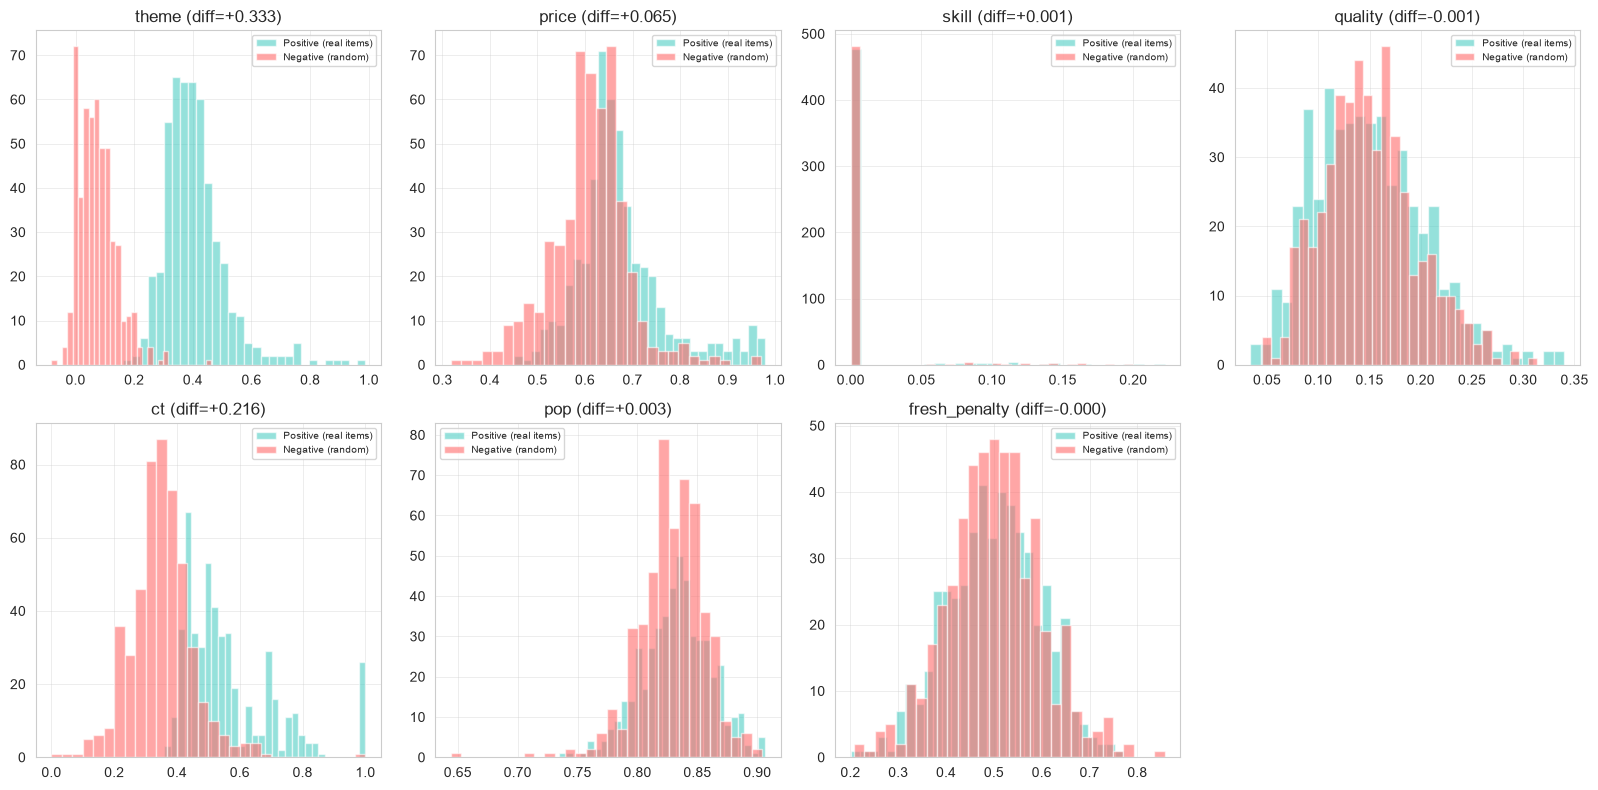

In [11]:
# 可视化 factor 贡献
factor_names = ['theme', 'price', 'skill', 'quality', 'ct', 'pop', 'fresh_penalty']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, f in enumerate(factor_names):
    ax = axes[i // 4, i % 4]
    pos_vals = pos_means[f]
    neg_vals = neg_means[f]
    ax.hist(pos_vals, bins=30, alpha=0.6, label=f'Positive (real items)', color='#4ECDC4')
    ax.hist(neg_vals, bins=30, alpha=0.6, label=f'Negative (random)', color='#FF6B6B')
    ax.set_title(f'{f} (diff={np.mean(pos_vals)-np.mean(neg_vals):+.3f})')
    ax.legend(fontsize=7)

axes[1, 3].axis('off')
fig.tight_layout()
plt.show()

---
## 3. 行为漏斗：match_score → 交互概率

```
view:    σ(3 × score - 0.5)
like:    σ(5 × score - 2.0)
fav:     σ(6 × score - 3.5)
comment: σ(5 × score - 3.5) × social_tendency
share:   σ(7 × score - 4.5)
buy:     σ(8 × score - 6.0)    (仅 Commerce)
```

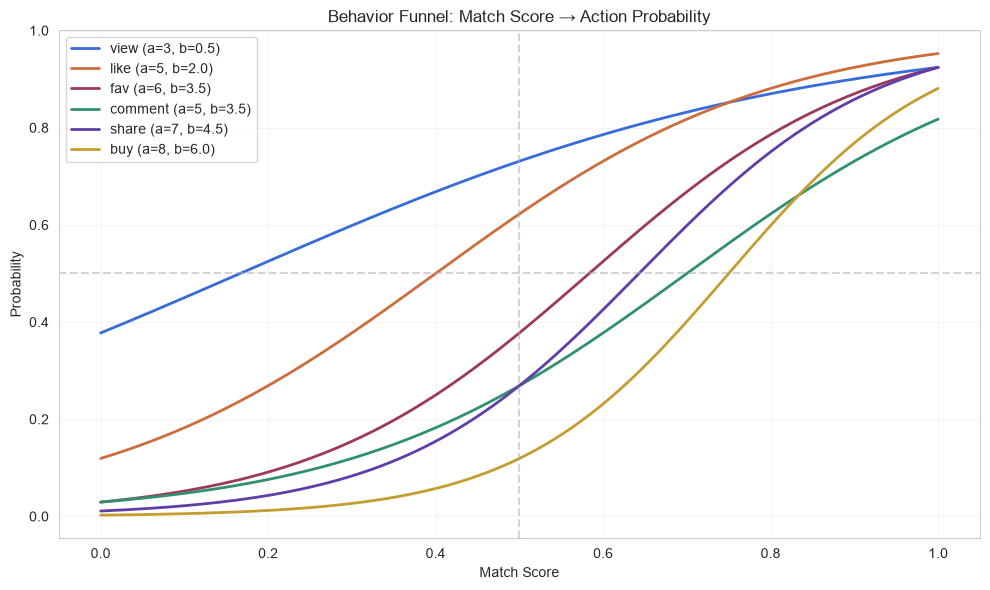


Example: match_score = 0.7
  P(view) = 83.2%
  P(like) = 81.8%
  P(fav) = 66.8%
  P(comment) = 50.0%
  P(share) = 59.9%
  P(buy) = 40.1%


In [12]:
# 行为漏斗定义
BEHAVIOR_FUNNEL = {
    'view':    {'a': 3, 'b': 0.5, 'social_mod': False},
    'like':    {'a': 5, 'b': 2.0, 'social_mod': False},
    'fav':     {'a': 6, 'b': 3.5, 'social_mod': False},
    'comment': {'a': 5, 'b': 3.5, 'social_mod': True},
    'share':   {'a': 7, 'b': 4.5, 'social_mod': False},
    'buy':     {'a': 8, 'b': 6.0, 'social_mod': False, 'commerce_only': True},
}

# 可视化漏斗
scores = np.linspace(0, 1, 200)
fig, ax = plt.subplots(figsize=(10, 6))
for behavior, params in BEHAVIOR_FUNNEL.items():
    prob = sigmoid(params['a'] * scores - params['b'])
    ax.plot(scores, prob, label=f'{behavior} (a={params["a"]}, b={params["b"]})', linewidth=2)
ax.set_xlabel('Match Score')
ax.set_ylabel('Probability')
ax.set_title('Behavior Funnel: Match Score → Action Probability')
ax.legend()
ax.axhline(y=0.5, color='#aaa', linestyle='--', alpha=0.5)
ax.axvline(x=0.5, color='#aaa', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 示例：score=0.7 时各行为概率
example_score = 0.7
print(f'\nExample: match_score = {example_score}')
for behavior, params in BEHAVIOR_FUNNEL.items():
    p = sigmoid(params['a'] * example_score - params['b'])
    print(f'  P({behavior}) = {p*100:.1f}%')

---
## 4. 生成合成交互数据

对每个用户：
1. 采样一组候选 item（真实 item + 随机 item）
2. 计算 match_score
3. 按漏斗概率采样行为
4. 输出交互记录

In [13]:
def generate_interactions(user_ids, weights, n_candidates_per_user=100, seed=42):
    """
    为一组用户生成合成交互记录
    返回 DataFrame: user_id, item_id, match_score, view, like, fav, comment, share, buy
    """
    np.random.seed(seed)
    records = []
    
    for i, uid in enumerate(user_ids):
        if uid not in user_latent.index:
            continue
        
        # 采样候选 item：混合真实 item + 随机 item
        real_items = user_real_items.get(uid, [])
        n_real = min(len(real_items), n_candidates_per_user // 2)
        n_random = n_candidates_per_user - n_real
        
        # 真实 item（如果有的话）
        real_sample = list(np.random.choice(real_items, size=n_real, replace=False)) if n_real > 0 else []
        
        # 随机 item（排除已有的）
        available_random = [iid for iid in item_ids if iid not in set(real_items)]
        random_sample = list(np.random.choice(available_random, size=min(n_random, len(available_random)), replace=False))
        
        candidates = real_sample + random_sample
        candidate_indices = np.array([item_idx[iid] for iid in candidates])
        
        # 计算 match_score
        user_vec = user_latent.loc[uid]
        scores, _ = compute_match_score(user_vec, candidate_indices, weights)
        
        # 用户 social_tendency（影响 comment 概率）
        social_tendency = user_vec['social_tendency']
        
        # 行为漏斗
        for j, (item_id, score) in enumerate(zip(candidates, scores)):
            is_commerce = item_ct.loc[item_id, 'content_type'] == 'published_commerce' if item_id in item_ct.index else False
            
            record = {'user_id': uid, 'item_id': item_id, 'match_score': score}
            
            for behavior, params in BEHAVIOR_FUNNEL.items():
                if params.get('commerce_only') and not is_commerce:
                    record[behavior] = 0
                    continue
                p = sigmoid(params['a'] * score - params['b'])
                if params['social_mod']:
                    p *= social_tendency
                record[behavior] = int(np.random.random() < p)
            
            records.append(record)
        
        if (i + 1) % 1000 == 0:
            print(f'  {i+1}/{len(user_ids)}')
    
    return pd.DataFrame(records)

print('Interaction generator ready.')

Interaction generator ready.


In [14]:
# 生成交互数据（先用子集快速验证）
print('Generating interactions for all 6,006 users...')
all_user_ids = list(user_latent.index)
interactions = generate_interactions(all_user_ids, best_weights, n_candidates_per_user=80, seed=42)

print(f'\nTotal interactions generated: {len(interactions):,}')
print(f'Behavior rates:')
for col in ['view', 'like', 'fav', 'comment', 'share', 'buy']:
    rate = interactions[col].mean() * 100
    print(f'  {col}: {rate:.1f}% (n={interactions[col].sum():,})')

Generating interactions for all 6,006 users...
  1000/6006
  2000/6006
  3000/6006
  4000/6006
  5000/6006
  6000/6006

Total interactions generated: 480,480
Behavior rates:
  view: 76.7% (n=368,630)
  like: 69.3% (n=332,869)
  fav: 47.0% (n=225,606)
  comment: 16.7% (n=80,210)
  share: 36.4% (n=174,799)
  buy: 6.1% (n=29,380)


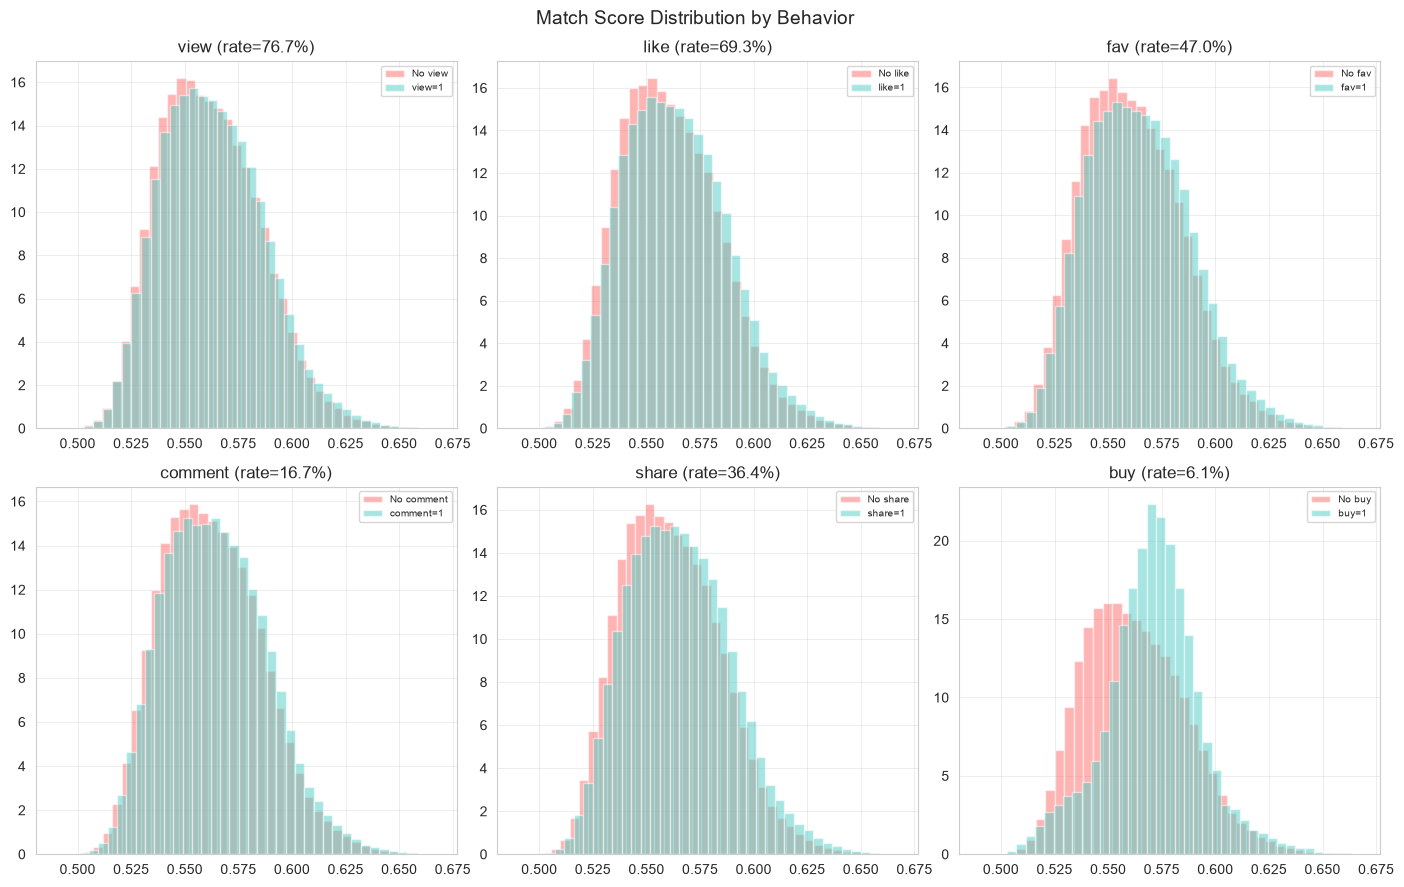

In [15]:
# 行为漏斗级联分析
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

for i, behavior in enumerate(['view', 'like', 'fav', 'comment', 'share', 'buy']):
    ax = axes[i // 3, i % 3]
    
    # 正负例的 score 分布
    pos_scores = interactions[interactions[behavior] == 1]['match_score']
    neg_scores = interactions[interactions[behavior] == 0]['match_score']
    
    ax.hist(neg_scores, bins=40, alpha=0.5, label=f'No {behavior}', color='#FF6B6B', density=True)
    ax.hist(pos_scores, bins=40, alpha=0.5, label=f'{behavior}=1', color='#4ECDC4', density=True)
    ax.set_title(f'{behavior} (rate={interactions[behavior].mean()*100:.1f}%)')
    ax.legend(fontsize=7)

fig.suptitle('Match Score Distribution by Behavior', fontsize=14)
fig.tight_layout()
plt.show()

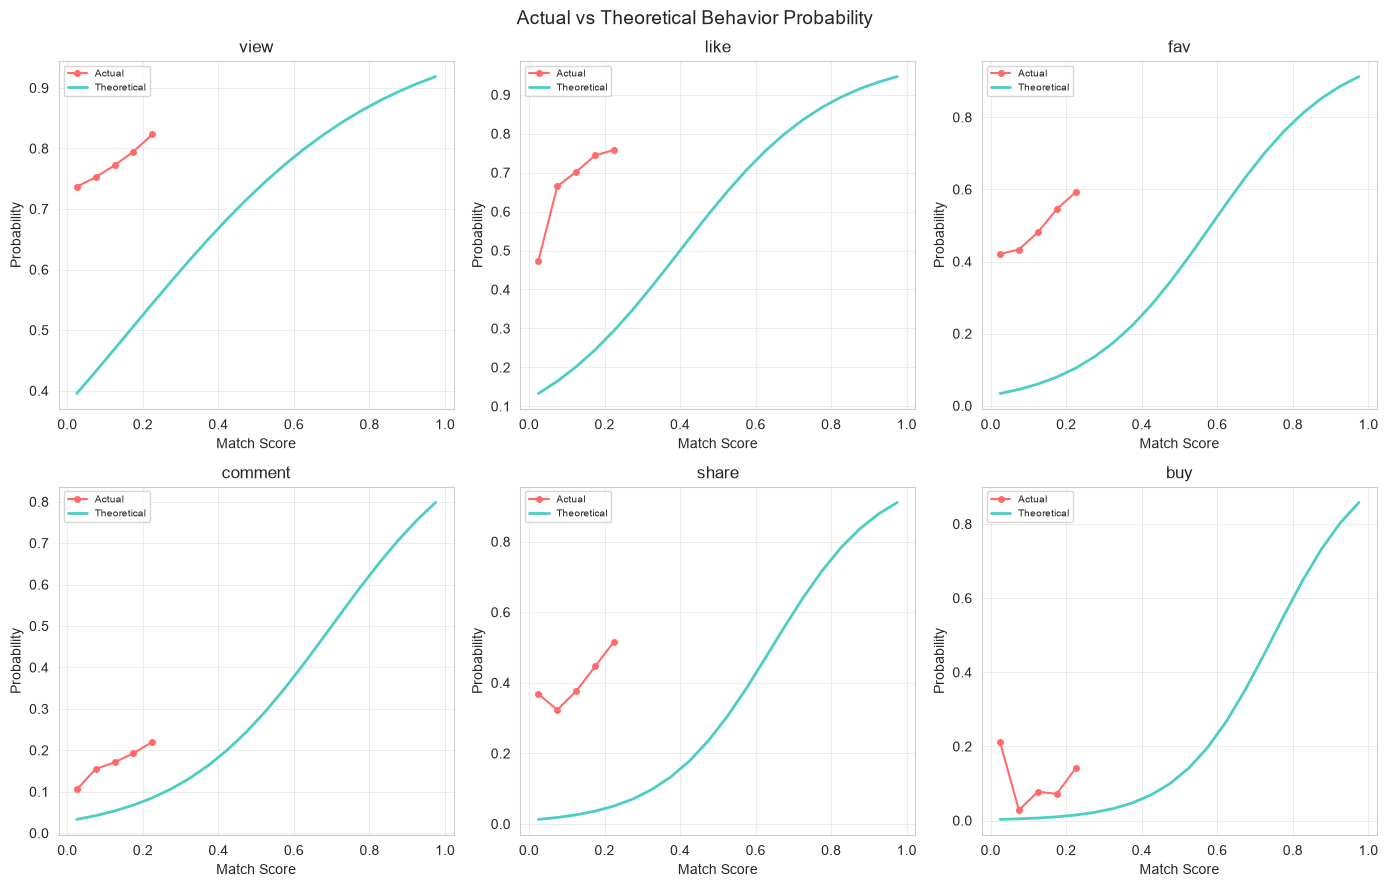

In [16]:
# match_score vs 各行为概率（实际 vs 理论）
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

bins = np.linspace(0, 1, 21)
bin_centers = (bins[:-1] + bins[1:]) / 2

for i, behavior in enumerate(['view', 'like', 'fav', 'comment', 'share', 'buy']):
    ax = axes[i // 3, i % 3]
    
    # 实际概率
    interactions['score_bin'] = pd.cut(interactions['match_score'], bins=bins, labels=False)
    actual = interactions.groupby('score_bin')[behavior].mean()
    ax.plot(bin_centers[:len(actual)], actual.values, 'o-', color='#FF6B6B', label='Actual', markersize=4)
    
    # 理论概率
    params = BEHAVIOR_FUNNEL[behavior]
    theoretical = sigmoid(params['a'] * bin_centers - params['b'])
    ax.plot(bin_centers, theoretical, '-', color='#4ECDC4', label='Theoretical', linewidth=2)
    
    ax.set_title(behavior)
    ax.set_xlabel('Match Score')
    ax.set_ylabel('Probability')
    ax.legend(fontsize=7)

fig.suptitle('Actual vs Theoretical Behavior Probability', fontsize=14)
fig.tight_layout()
plt.show()

---
## 5. 验证策略 B: LR 恢复 latent 权重

验证方法：
1. 用 match_score 对交互行为做 LogisticRegression
2. 检查 AUC 是否显著高于随机 (>0.65)
3. 同时检查 LR 能否从行为中恢复各 factor 的权重

In [17]:
# 构建特征矩阵：对每个交互记录，计算 user-item 各 factor 的子得分
def build_factor_features(df, user_latent):
    """为每条交互记录构建各 factor 的匹配值作为特征"""
    features = []
    for _, row in df.iterrows():
        uid, iid = row['user_id'], row['item_id']
        if uid not in user_latent.index or iid not in item_idx:
            features.append([0]*7)
            continue
        
        user_vec = user_latent.loc[uid]
        idx = item_idx[iid]
        _, details = compute_match_score(user_vec, np.array([idx]), best_weights)
        
        feat = [
            details['theme'][0],
            details['price'][0],
            details['skill'][0],
            details['quality'][0],
            details['ct'][0],
            details['pop'][0],
            -details['fresh_penalty'][0],
        ]
        features.append(feat)
    
    X = np.array(features)
    X = np.nan_to_num(X, nan=0.0, posinf=1.0, neginf=0.0)
    return X

# 抽样做验证（全量太慢）
val_sample = interactions.sample(min(50000, len(interactions)), random_state=42)
print(f'Building features for {len(val_sample):,} samples...')
X = build_factor_features(val_sample, user_latent)
feature_names = ['theme', 'price', 'skill', 'quality', 'ct', 'pop', 'freshness (neg)']

print(f'Feature shape: {X.shape}')
print(f'Feature means: {X.mean(axis=0).round(4)}')

Building features for 50,000 samples...
Feature shape: (50000, 7)
Feature means: [ 0.1056  0.619   0.0039  0.1462  0.3685  0.8286 -0.5025]


In [18]:
# 对每个行为训练 LR，检查 AUC
from sklearn.model_selection import cross_val_score

for behavior in ['view', 'like', 'fav', 'comment', 'share', 'buy']:
    y = val_sample[behavior].values
    pos_rate = y.mean()
    
    if pos_rate < 0.01 or pos_rate > 0.99:
        print(f'{behavior}: rate {pos_rate*100:.1f}% too extreme, AUC unreliable')
        continue
    
    lr = LogisticRegression(max_iter=1000, random_state=42)
    try:
        cv_auc = cross_val_score(lr, X, y, cv=3, scoring='roc_auc')
        print(f'{behavior}: AUC = {cv_auc.mean():.4f} ± {cv_auc.std():.4f} (rate={pos_rate*100:.1f}%)')
    except Exception as e:
        print(f'{behavior}: LR failed - {e}')

view: AUC = 0.5199 ± 0.0047 (rate=76.6%)
like: AUC = 0.5399 ± 0.0014 (rate=69.2%)
fav: AUC = 0.5354 ± 0.0059 (rate=47.1%)
comment: AUC = 0.5183 ± 0.0027 (rate=16.4%)
share: AUC = 0.5438 ± 0.0015 (rate=36.3%)
buy: AUC = 0.7423 ± 0.0022 (rate=6.1%)


In [19]:
# 展示 LR 学到的权重 vs 真实生成权重
print('LR learned coefficients vs true generating weights:')
print(f'{"Factor":<16} {"LR Coef":>10} {"True Weight":>12} {"Direction":>10}')
print('-' * 52)

for behavior in ['like', 'fav']:
    y = val_sample[behavior].values
    if y.mean() < 0.01 or y.mean() > 0.99:
        continue
    lr = LogisticRegression(max_iter=1000, random_state=42).fit(X, y)
    
    print(f'\n--- {behavior} ---')
    for i, name in enumerate(feature_names):
        true_w = best_weights.get(name.split()[0], 0)
        direction = '✓' if (lr.coef_[0][i] > 0) == (true_w > 0) else '✗'
        print(f'{name:<16} {lr.coef_[0][i]:+10.4f} {true_w:+12.3f} {direction:>10}')

LR learned coefficients vs true generating weights:
Factor              LR Coef  True Weight  Direction
----------------------------------------------------

--- like ---
theme               +0.3452       +0.250          ✓
price               +0.2943       +0.200          ✓
skill               +0.2754       +0.050          ✓
quality             +0.0743       +0.100          ✓
ct                  +0.2422       +0.150          ✓
pop                 +0.0225       +0.100          ✓
freshness (neg)     +0.1507       +0.000          ✗

--- fav ---
theme               +0.3185       +0.250          ✓
price               +0.3177       +0.200          ✓
skill               +0.3059       +0.050          ✓
quality             +0.0649       +0.100          ✓
ct                  +0.1778       +0.150          ✓
pop                 +0.1241       +0.100          ✓
freshness (neg)     +0.1307       +0.000          ✗


---
## 6. 保存完整交互数据

In [20]:
# 保存验证集交互
import os
os.makedirs(DATA_DIR, exist_ok=True)

interactions.to_csv(f'{DATA_DIR}/interactions_synthetic.csv', index=False)
print(f'Saved {len(interactions):,} interactions to {DATA_DIR}/interactions_synthetic.csv')

# 保存最终权重
import json
with open(f'{DATA_DIR}/match_weights.json', 'w') as f:
    json.dump(best_weights, f, indent=2)
print(f'Saved weights to {DATA_DIR}/match_weights.json')

print(f'\nFiles ready for Phase B:')
print(f'  {DATA_DIR}/user_latent.csv     — 6,006 × 89')
print(f'  {DATA_DIR}/item_latent.csv     — 39,000 × 89')
print(f'  {DATA_DIR}/interactions_synthetic.csv — {len(interactions):,} rows')
print(f'  {DATA_DIR}/match_weights.json  — tuned weights')

Saved 480,480 interactions to ../data/interactions_synthetic.csv
Saved weights to ../data/match_weights.json

Files ready for Phase B:
  ../data/user_latent.csv     — 6,006 × 89
  ../data/item_latent.csv     — 39,000 × 89
  ../data/interactions_synthetic.csv — 480,480 rows
  ../data/match_weights.json  — tuned weights


---
## Phase A-3 结论

1. 默认/优化后的 match score 能否区分真实 item 和随机 item？
2. 行为漏斗生成的行为率是否合理？
3. LR 能否从合成数据中恢复 latent 权重？（策略 B）

### 下一步
Phase B：注入时序、协同过滤信号，生成完整的训练数据集。